### Retrievers

A retriever is an interface that returns documents given an `unstructured query`. 

A retriever does not need to be able to store documents, only to return (or retrieve) them. 
Retrievers can be created from vector stores, but are also broad enough to include external search or api calls, db queries.

> Retrievers accept a string query as input and return a list of Documents as output.

Note that all vector stores can be cast to retrievers. 

In [ ]:
!uv pip install -qU wikipedia arxiv pymupdf

In [1]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.retrievers import WikipediaRetriever, ArxivRetriever
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
import json
from langchain_core.documents import Document
#deserialize from jsonl file
source_file = '../tmp/documents.jsonl'
documents = []
with open(source_file, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        doc = Document(
            page_content=record['page_content'],
            metadata=record['metadata']
        )
        documents.append(doc)
print(f"Deserialized {len(documents)} documents from {source_file}")
embeddings = HuggingFaceEmbeddings(    
    model_name="Qwen/Qwen3-Embedding-0.6B",  #google/embeddinggemma:300m
    model_kwargs={'device': device}  
)
vector_store = InMemoryVectorStore.from_documents(documents, embeddings)
_kb_retriever = vector_store.as_retriever(
    search_type="similarity", # similarity (cosine), mmr (maximal marginal relevance), similarity_score_threshold
    search_kwargs={"k": 10}, # number of documents to retrieve
)
_wiki_retriever = WikipediaRetriever(
    lang="en", #language of the articles
    top_k_results=3, #max results to return
    load_max_docs=5, #max downloaded documents
    load_all_available_meta=False, #Published,Title,Summary
    )
_arxiv_retriever = ArxivRetriever(
    top_k_results=3, #max results to return
    load_max_docs=5, #max downloaded documents   
    load_all_available_meta=False, #Published,Title,Authors,Summary
    get_full_documents=True #fetch full text of the papers
    )

# Wrap synchronous retrievers in async
async def async_retrieve(retriever, query: str):
    """Run retriever in thread pool to avoid blocking"""
    retrieved_docs = await retriever.ainvoke(query)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs    
    
@tool(response_format="content_and_artifact")
async def kb(query: str):
    """Retrieve information from course materials, documentation and code snippets about AI, LLMs and related topics."""
    return await async_retrieve(_kb_retriever, query)
@tool(response_format="content_and_artifact")
async def wikipedia(query: str):
    """Retrieve information from Wikipedia for general knowledge and fact checking."""
    return await async_retrieve(_wiki_retriever, query)
@tool(response_format="content_and_artifact")
async def arxiv(query: str):
    """Retrieve information from arXiv for academic research papers."""
    return await async_retrieve(_arxiv_retriever, query)

from langchain.chat_models import init_chat_model
model = "granite4:3b-h"
llm = init_chat_model(
    model_provider="ollama",
    model=model,
    # kwargs passed to the model:
    temperature=0,
    timeout=30,
    max_tokens=1000,
)
prompt = (
    "You are an assistant of an AI engineering course, your goal is to help students to improve their skills.\n"
    "Use ALWAYS the tool `kb`, that contains course material, documentation and code snippets about AI, LLMs and related topics.\n"
    "Optionally use other tools to access external resources to help answer student queries."
    "In any case cite the sources with links."
)
agent = create_agent(llm, [kb, wikipedia, arxiv], system_prompt=prompt)

Deserialized 736 documents from ../tmp/documents.jsonl


/home/admin/_github/massimodipaolo/ai-crash-course/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


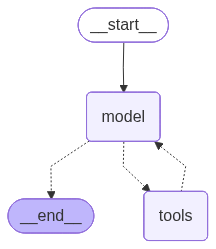

In [3]:
# agent diagram
from PIL import Image
from io import BytesIO
graph = await agent.aget_graph()
png = graph.draw_mermaid_png()
display(Image.open(BytesIO(png)))


In [3]:
messages = [{"role": "user", "content": "Who are the main authors of the paper 'Attention is all you need'?" }]
_rs = await agent.ainvoke({"messages": messages})

import markdown
from IPython.core.display import HTML
for msg in _rs['messages']:
    # skip tool call messages and tool responses
    if msg.type in ['assistant', 'human']:  
        _content = markdown.markdown(msg.content)
        display(HTML(_content))